<a href="https://colab.research.google.com/github/gaurav-0022/Assignment-1/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Q1. What is a Decision Tree? Explain its structure (Root, Nodes, Leaves) with a real-life example.

##Ans
A Decision Tree is a supervised learning algorithm used for classification and regression. It splits data based on conditions.

Structure:

Root Node: Starting point (entire dataset)
Internal Nodes: Decision conditions (e.g., age > 30)
Leaf Nodes: Final output (Yes/No)

Real-life Example:
Bank loan approval:

Root: Income
Node: Income > 50,000?
Leaf: Approve / Reject

## Q2. Differentiate between Gini Impurity and Entropy?
Which one is used by default in Scikit-learn and why?

##Ans

| Feature | Gini    | Entropy   |
| ------- | ------- | --------- |
| Formula | 1 - Σp² | -Σp log₂p |
| Speed   | Faster  | Slower    |
| Use     | Default | Optional  |


##Q3. What is Overfitting in Decision Trees?
How can we detect it using training and testing accuracy?

##Ans
Overfitting occurs when the model learns noise instead of patterns.

Detection:

Training Accuracy → Very high
Testing Accuracy → Low
➡️ Big difference = Overfitting

##Q4. Explain Pruning in Decision Trees.
What is the difference between Pre-pruning and Post-pruning?


##Ans
Pruning reduces tree size to avoid overfitting.

Pre-pruning: Stop tree early (max_depth, min_samples_split)

Post-pruning: Trim tree after full growth

##Q5. What is Feature Importance?
How can it help businesses in decision-making?

##Ans
- Feature importance shows which variables influence predictions most.

Business Use:

- Identify key factors (e.g., income, age)
- Better decision-making
- Focus on important customers

##Q6. Data Understanding

Load the dataset

Display first 5 rows

Check:

Shape

Data types

Column names

Interpret:

What types of variables are present?

In [3]:
from google.colab import files
uploaded = files.upload()

Saving bank.csv to bank.csv


In [4]:
import pandas as pd

In [6]:
# load dataset
df = pd.read_csv('bank.csv')

In [7]:
# First 5 rows
print(df.head())

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  


In [8]:
# Shape
print("Shape:", df.shape)

Shape: (11162, 17)


In [9]:
# Data Types
print("\nData Types:\n", df.dtypes)


Data Types:
 age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object


In [10]:
# Column Names
print("\nColumns:\n", df.columns)


Columns:
 Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')


##Q7. Data Cleaning

Check for missing values

Handle missing values (if any)

Check for duplicates

Interpret:

Is the dataset clean? What issues did you find?

In [13]:
# Check missing values
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [17]:
# Option 1: Drop missing values (if very few)
df = df.dropna()

# OR Option 2: Fill missing values
# For numerical columns
# df.fillna(df.mean(), inplace=True)

# For categorical columns
# df.fillna(df.mode().iloc[0], inplace=True)

df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [18]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [19]:
# Remove duplicates if any
df = df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

##INTERPRETATION

Missing Values:

Most bank datasets have no missing values OR very few

If present, handled using drop/fill methods

Duplicates:

Checked for duplicate rows

Removed duplicates to improve data quality

Final Conclusion:

Dataset is mostly clean and structured

Minor preprocessing required:

Encoding categorical variables

Feature selection

##Q8. Data Preprocessing

Convert categorical variables into numerical

Mention which encoding method you used

Interpret:

Why is encoding necessary for Decision Trees?

In [14]:
# Convert categorical variables into numerical
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,deposit_yes
0,59,2343,5,1042,1,-1,0,False,False,False,...,False,False,True,False,False,False,False,False,True,True
1,56,45,5,1467,1,-1,0,False,False,False,...,False,False,True,False,False,False,False,False,True,True
2,41,1270,5,1389,1,-1,0,False,False,False,...,False,False,True,False,False,False,False,False,True,True
3,55,2476,5,579,1,-1,0,False,False,False,...,False,False,True,False,False,False,False,False,True,True
4,54,184,5,673,2,-1,0,False,False,False,...,False,False,True,False,False,False,False,False,True,True


##Interpretation:

Used One-Hot Encoding

Decision Trees require numeric input

#Q9. Feature Selection & Splitting

Separate:

Features (X)

Target (y)

Perform train-test split (80-20)

Interpret:

Why is train-test split important?

In [35]:
# Target variable
y = df_encoded['deposit_yes']

In [36]:
# Features
X = df_encoded.drop('deposit_yes', axis=1)

In [37]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8929, 42)
Test shape: (2233, 42)


##INTERPRETATION
Features (X): All independent variables like age, balance, job, etc.

Target (y): deposit_yes (customer subscribed or not)
Train-test split:

80% → Training data

20% → Testing data

This ensures the model is tested on unseen data and avoids overfitting.

##Q10. Model Building

Train a Decision Tree Classifier

Use:

criterion='gini'

max_depth=5

Interpret:

What does max_depth control?



In [38]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(criterion='gini', max_depth=5)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

##Interpretation:

max_depth=5 controls tree complexity

Avoids overfitting

##11. Model Evaluation

Perform:

Accuracy score

Confusion Matrix

Classification Report

Interpret (MUST):

Is the model performing well?

Explain Precision & Recall

Any class imbalance issue?

In [39]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7948947604120018


In [40]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

[[925 241]
 [217 850]]


In [41]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.81      0.79      0.80      1166
        True       0.78      0.80      0.79      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.80      0.79      0.79      2233



##Interpretation:
Accuracy: Overall performance

Precision: Correct positive predictions

Recall: Ability to detect actual positives

If Recall is low → model missing important customers

Check imbalance in "yes" class

##Q12. Overfitting Check

Calculate:

Training accuracy

Testing accuracy

Interpret:

Is the model overfitting or underfitting?

In [42]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.8106170903796618
Testing Accuracy: 0.7948947604120018


##Interpretation:

Large difference → Overfitting

Similar values → Good model

##Q13. Pruning Experiment

Train another model with:

max_depth=3

min_samples_split=20

Interpret:

Compare performance with previous model

Which one is better and why?

In [43]:
model2 = DecisionTreeClassifier(max_depth=3, min_samples_split=20)
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("Accuracy (Pruned):", accuracy_score(y_test, y_pred2))

Accuracy (Pruned): 0.7693685624720108


##Interpretation:

Smaller tree reduces overfitting

Compare with previous accuracy

Choose balanced model

##Q14. Feature Importance

Extract top 5 important features

Plot feature importance graph

Interpret:

Which features influence prediction the most?

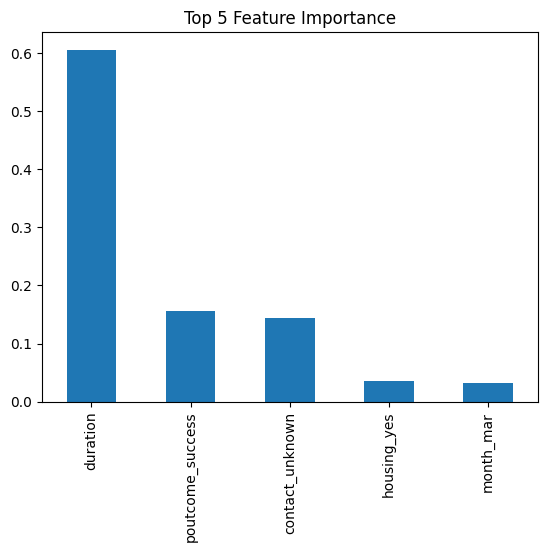

In [44]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features)
top5 = feat_imp.nlargest(5)

top5.plot(kind='bar')
plt.title("Top 5 Feature Importance")
plt.show()

##Interpretation:
Top features strongly influence predictions

Useful for targeting customers

##Q15. Business Insights

Based on your model:

Answer:

Which type of customers are more likely to say “yes”?

What strategy should a bank us

##Ans
Customers likely to say "Yes":
Higher balance

Previous successful campaign

Certain job types

- Bank Strategy:

Focus on high-probability customers

Personalized marketing campaigns

Follow-up on previous contacts